# FMU State Rollback for Zero-Crossing Detection

## FMU using Explicit Euler Integration

- Explicit Euler allows for FMI 2.0 CS FMU to use `fmu.getFMUState()` and `fmu.setFMUState(state)`.
- This enables saving and restoring FMU states for zero-crossing detection.

**Limitations:**
- This approach is specific to FMUs that support state saving/restoring.
- This approach in not applicable for FMUs using CVODE integrators, as they maintain an internal state that cannot be easily manipulated.
- Explicit Euler is less accurate and stable compared to more advanced integrators like CVODE.
- A reduced global step size `dt` is neceassary to ensure a stable simulation and accurate zero-crossing detection within the maximum number of bisection iterations.

In [81]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [82]:
from OMPython import ModelicaSystem
from shutil import move

pkg_file = Path.cwd().parent / 'Modelica/ControlledPendulum/package.mo'
model_name = 'ControlledPendulum.Pendulum'
solver_euler = "euler"
solver_cvode = "cvode"
model_euler = ModelicaSystem(str(pkg_file), model_name, commandLineOptions=f"--fmiFlags=s:{solver_euler}")
model_cvode = ModelicaSystem(str(pkg_file), model_name, commandLineOptions=f"--fmiFlags=s:{solver_cvode}")
model_euler.buildModel()
model_cvode.buildModel()

fmu_path_euler = model_euler.convertMo2Fmu(fmuType='cs')
fmu_path_cvode = model_cvode.convertMo2Fmu(fmuType='cs')

dest_path_euler = Path.cwd().parent / 'FMUs/Pendulum_Euler.fmu'
move(fmu_path_euler, dest_path_euler)

dest_path_cvode = Path.cwd().parent / 'FMUs/Pendulum_Cvode.fmu'
move(fmu_path_cvode, dest_path_cvode)

print(f"FMU saved to: {dest_path_euler}")
print(f"FMU saved to: {dest_path_cvode}")


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.



FMU saved to: /home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Pendulum_Euler.fmu
FMU saved to: /home/flo/code/SystemSimulation/demos/ControlledPendulum/MyModels/FMUs/Pendulum_Cvode.fmu


--------------------------

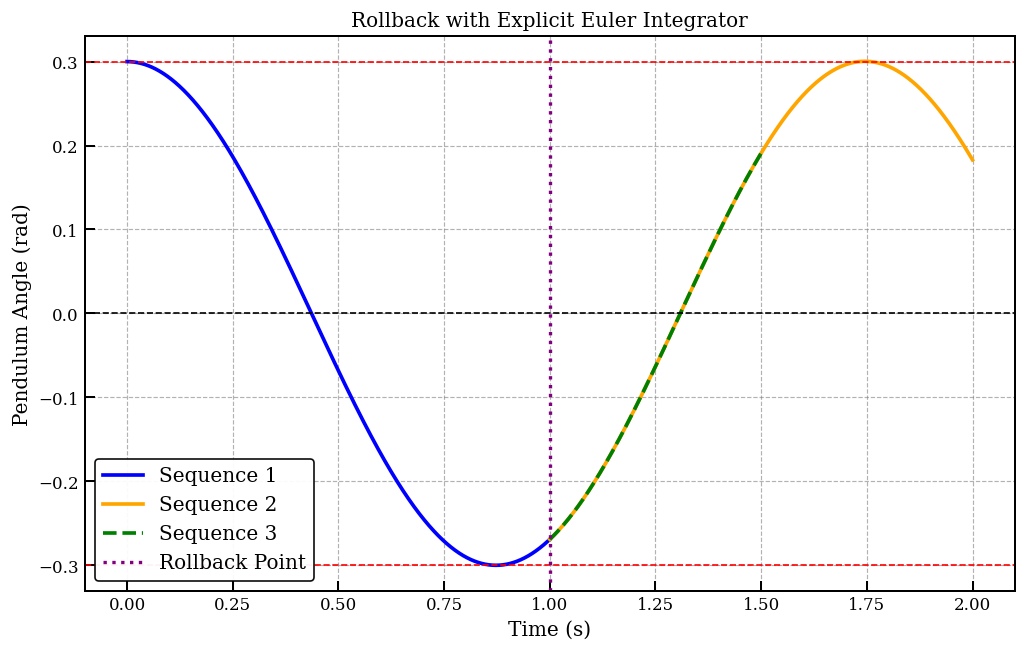

In [ ]:
pendulum_euler = FMUComponent(name="Pendulum_Euler", fmu_path=str(dest_path_euler))
pendulum_euler.set_parameters(q0=0.3)
pendulum_euler.initialize(0.0)
fmu_euler = pendulum_euler._instance

vars = pendulum_euler._md_vars
omega0_vr = vars.get('omega0').valueReference
q0_vr = vars.get('q0').valueReference
omega_vr = vars.get('omega').valueReference
q_vr = vars.get('q').valueReference

t_vals_1 = []
t_vals_2 = []
t_vals_3 = []
q_vals_1 = []
q_vals_2 = []
q_vals_3 = []

# Sequence 1
t = 0.0
dt = 1e-4
end_time = 1.0

while t < end_time:
    fmu_euler.doStep(t, dt)
    q = fmu_euler.getReal([q_vr])[0]
    t_vals_1.append(t)
    q_vals_1.append(q)
    t += dt

state_1s = fmu_euler.getFMUState()
t_state = t

# Sequence 2
end_time = 2.0
while t < end_time:
    fmu_euler.doStep(t, dt)
    q = fmu_euler.getReal([q_vr])[0]
    t_vals_2.append(t)
    q_vals_2.append(q)
    t += dt

# Restore state from end of sequence 1
fmu_euler.setFMUState(state_1s)
t = t_state
end_time = 1.5
while t < end_time:
    fmu_euler.doStep(t, dt)
    q = fmu_euler.getReal([q_vr])[0]
    t_vals_3.append(t)
    q_vals_3.append(q)
    t += dt

# Plot results
plt.figure(figsize=(10, 6))
plt.title('Rollback with Explicit Euler Integrator')
plt.plot(t_vals_1, q_vals_1, label='Sequence 1', color='blue')
plt.plot(t_vals_2, q_vals_2, label='Sequence 2', color='orange')
plt.plot(t_vals_3, q_vals_3, label='Sequence 3', color='green', linestyle='--')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axhline(0.3, color='red', linewidth=1, linestyle='--')
plt.axhline(-0.3, color='red', linewidth=1, linestyle='--')
plt.axvline(t_state, color='purple', linewidth=2, linestyle=':', label='Rollback Point')
plt.xlabel('Time (s)')
plt.ylabel('Pendulum Angle (rad)')
plt.grid()
plt.legend(loc='lower left')
plt.show()

In [89]:
type(state_1s)

ctypes.c_void_p

- The FMU component set up with the Explicit Euler integrator allows the state saving and restoring functionality needed for zero-crossing detection.
- Since the Explicit Euler method does not have an internal state, it is possible to manipulate the FMU state directly.
- This allows to save the state at a time $t_n$, continue the simulation to $t_{n+1}$, restore the state at $t_n$ and continue the simulation
- Since the Explicit Euler method is less accurate, a smaller global step size `dt` is necessary to ensure accurate simulation results

------------

## FMU using CVODE Integration
- CVODE does not support `fmu.getFMUState()` and `fmu.setFMUState(state)`, making state restoration impossible.
- For simple FMUs, the state needs to be made manually accesible via model variables. 
- Furthermore, one needs to reinitialize the FMU at the crossing point by setting the model variables directly.
- This approach is more error-prone and may not work for complex models with many states or algebraic loops.
- The FMU is reinitialized at the crossing point with the new state (with swapped velocity in this case) to continue the simulation.

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

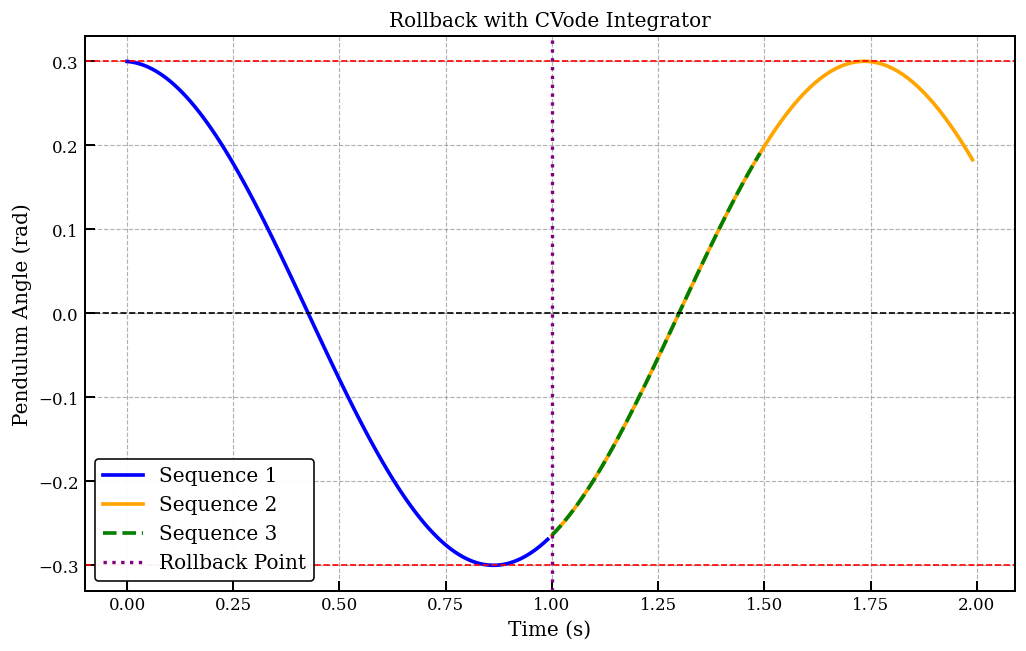

In [90]:
pendulum_cvode = FMUComponent(name="Pendulum_Cvode", fmu_path=str(dest_path_cvode))
pendulum_cvode.set_parameters(q0=0.3)
pendulum_cvode.initialize(0.0)
fmu_cvode = pendulum_cvode._instance

vars = pendulum_cvode._md_vars
omega0_vr = vars.get('omega0').valueReference
q0_vr = vars.get('q0').valueReference
omega_vr = vars.get('omega').valueReference
q_vr = vars.get('q').valueReference

t_vals_1 = []
t_vals_2 = []
t_vals_3 = []
q_vals_1 = []
q_vals_2 = []
q_vals_3 = []

# Sequence 1
t = 0.0
dt = 0.01
end_time = 1.0

while t < end_time:
    fmu_cvode.doStep(t, dt)
    q = fmu_cvode.getReal([q_vr])[0]
    t_vals_1.append(t)
    q_vals_1.append(q)
    t += dt

state_1s = fmu_cvode.getFMUState()
t_state = t
q0 = fmu_cvode.getReal([q_vr])[0]
omega0 = fmu_cvode.getReal([omega_vr])[0]

# Sequence 2
end_time = 2.0
while t < end_time:
    fmu_cvode.doStep(t, dt)
    q = fmu_cvode.getReal([q_vr])[0]
    t_vals_2.append(t)
    q_vals_2.append(q)
    t += dt

# Restore state from end of sequence 1
fmu_cvode.reset()
fmu_cvode.instantiate()
fmu_cvode.setupExperiment(startTime=t_state)
fmu_cvode.enterInitializationMode()
fmu_cvode.setReal([q0_vr, omega0_vr], [q0, omega0])
fmu_cvode.exitInitializationMode()

t = t_state
end_time = 1.5
while t < end_time:
    fmu_cvode.doStep(t, dt)
    q = fmu_cvode.getReal([q_vr])[0]
    t_vals_3.append(t)
    q_vals_3.append(q)
    t += dt

# Plot results
plt.figure(figsize=(10, 6))
plt.title('Rollback with CVode Integrator')
plt.plot(t_vals_1, q_vals_1, label='Sequence 1', color='blue')
plt.plot(t_vals_2, q_vals_2, label='Sequence 2', color='orange')
plt.plot(t_vals_3, q_vals_3, label='Sequence 3', color='green', linestyle='--')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axhline(0.3, color='red', linewidth=1, linestyle='--')
plt.axhline(-0.3, color='red', linewidth=1, linestyle='--')
plt.axvline(t_state, color='purple', linewidth=2, linestyle=':', label='Rollback Point')
plt.xlabel('Time (s)')
plt.ylabel('Pendulum Angle (rad)')
plt.grid()
plt.legend(loc='lower left')
plt.show()

- If the FMU is set up with the CVode integrator, the state saving and restoring functionality via `fmu.getFMUState()` and `fmu.setFMUState(state)` is not available
- The CVode integrator maintains an internal state that cannot be easily manipulated.
- Therefore, the rollback approach requires that the FMU is re-initialized from scratch after restoring the state.
- This involves resetting the FMU, instantiating it again, setting the initial conditions, and exiting the initialization mode.
- This process is more complex and may introduce additional overhead compared to the Explicit Euler method.
- However, the CVode integrator provides better accuracy and stability for simulating dynamic systems. A larger global step size `dt` can be used while still achieving accurate results.

------------------------